In [1]:
# Imports
import pandas as pd
import numpy as np
import ast
import seaborn as sns
import xgboost as xgb
import optuna
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.neural_network import MLPRegressor
from collections import Counter

optuna.logging.set_verbosity(optuna.logging.WARNING)

In [2]:
# Constants
file_path = 'data.csv'
columns = [
    # 'id', 'name',

    # ── Host ──────────────────────────────────────────────────────────────────
    'host_is_superhost',              # experienced, highly-rated host — may command a price premium

    # ── Location (converted to distance_to_center later) ──────────────────────
    'latitude', 'longitude',          # raw coordinates → converted to distance from city centre

    # ── Listing type & size ───────────────────────────────────────────────────
    'room_type',                      # entire home vs private room — biggest categorical price driver
    'accommodates',                   # max number of guests; primary size signal and price driver
    'bathrooms',                      # more bathrooms = larger, more premium property
    'bathrooms_text',                 # raw text used to extract whether bathroom is shared or private
    'bedrooms',                       # number of bedrooms; complements accommodates for property size
    # 'beds' intentionally excluded — corr 0.805 with accommodates (redundant)

    # ── Amenities ─────────────────────────────────────────────────────────────
    'amenities',                      # raw list string → parsed into amenity_count + binary has_* flags

    # ── Target variable ───────────────────────────────────────────────────────
    'price',                          # nightly price in USD — what we are trying to predict

    # ── Quality & demand signals ──────────────────────────────────────────────
    'review_scores_location',         # guest-rated location score (1–5); captures perceived desirability
                                      # beyond just the borough. Stronger signal than review_scores_rating
                                      # (corr +0.132 vs +0.032 with price).
    'availability_365',               # days available per year; proxy for how actively a listing is priced

    # ── Geography ─────────────────────────────────────────────────────────────
    'neighbourhood_cleansed',         # standardised London borough → one-hot encoded into 33 binary columns

    # ── Host professionalism ──────────────────────────────────────────────────
    'calculated_host_listings_count', # number of active listings this host has; distinguishes professional
                                      # operators (many listings, higher/strategic pricing) from private
                                      # individuals. Strongest unused signal found (corr +0.218 with price).
]
# Source: https://www.latlong.net/place/london-uk-14153.html
london_center_lat = 51.509865
london_center_lon = -0.118092

# Random seeds — we train and evaluate the model once per seed, then average
# the results for a more reliable performance estimate than a single run.
seeds = [1, 7, 42, 67, 99]

In [3]:
# Load the raw dataset
df = pd.read_csv(file_path)

In [4]:
# Show the full dataframe without truncation — useful for initial exploration
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

print(df.columns.tolist())
print(df.head())

['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'calendar_updated', 'has_availability', 'availability_30', 'availability_60', 'availability_90', 'availabil

In [5]:
# Keep only the relevant columns and drop rows that have any missing values
df = df[columns].dropna()

In [6]:
# Explore the neighbourhood column before encoding it
print(df['neighbourhood_cleansed'].nunique())       # how many unique neighbourhoods?
print(df['neighbourhood_cleansed'].value_counts().head(10))

33
neighbourhood_cleansed
Westminster               6240
Kensington and Chelsea    3505
Camden                    3419
Tower Hamlets             3284
Hackney                   2520
Southwark                 2412
Wandsworth                2336
Lambeth                   2245
Islington                 2179
Hammersmith and Fulham    2097
Name: count, dtype: int64


In [7]:
# One-hot encode the neighbourhood column:
# Each neighbourhood becomes its own 0/1 column (e.g. nb_Westminster = 1 if the listing is there).
nb_dummies = pd.get_dummies(df['neighbourhood_cleansed'], prefix='nb', dtype=int)
df = pd.concat([df, nb_dummies], axis=1)
df = df.drop(columns='neighbourhood_cleansed')

In [8]:
def calculate_haversine_distance(lat_series, lon_series, center_lat, center_lon):
    """
    Calculate the straight-line distance (in meters) between each listing and a fixed point.

    Uses the Haversine formula, which correctly accounts for the Earth's curvature.
    The function is vectorized — it processes the entire column at once, which is very fast.
    """
    R = 6371000.0  # Earth's radius in meters

    # Convert degrees → radians (required for Python's trig functions)
    phi1         = np.radians(lat_series)
    phi2         = np.radians(center_lat)
    delta_phi    = np.radians(center_lat - lat_series)
    delta_lambda = np.radians(center_lon - lon_series)

    # Haversine formula
    a = np.sin(delta_phi / 2.0)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda / 2.0)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    return R * c

In [9]:
# Replace raw lat/lon with a single distance-to-center feature (in meters)
df['distance_to_center_m'] = calculate_haversine_distance(
    df['latitude'], df['longitude'],
    london_center_lat, london_center_lon
).round()

df = df.drop(columns=['latitude', 'longitude'])

In [10]:
print(df.dtypes)

host_is_superhost                     str
room_type                             str
accommodates                        int64
bathrooms                         float64
bathrooms_text                        str
bedrooms                          float64
amenities                             str
price                                 str
review_scores_location            float64
availability_365                    int64
calculated_host_listings_count      int64
nb_Barking and Dagenham             int64
nb_Barnet                           int64
nb_Bexley                           int64
nb_Brent                            int64
nb_Bromley                          int64
nb_Camden                           int64
nb_City of London                   int64
nb_Croydon                          int64
nb_Ealing                           int64
nb_Enfield                          int64
nb_Greenwich                        int64
nb_Hackney                          int64
nb_Hammersmith and Fulham         

In [11]:
# Convert 't'/'f' text values to 1/0 integers (1 = is a superhost)
df['host_is_superhost'] = (df['host_is_superhost'] == 't').astype(int)

In [12]:
# One-hot encode room type into four separate 0/1 columns
print(df['room_type'].unique())
df["is_private_room"] = (df["room_type"] == "Private room").astype(int)
df["is_entire_home"]  = (df["room_type"] == "Entire home/apt").astype(int)
df["is_hotel_room"]   = (df["room_type"] == "Hotel room").astype(int)
df["is_shared_room"]  = (df["room_type"] == "Shared room").astype(int)

df = df.drop(columns=['room_type'])

<StringArray>
['Private room', 'Entire home/apt', 'Hotel room', 'Shared room']
Length: 4, dtype: str


In [13]:
# Remove rare room types — hotel (41 listings) and shared (111 listings) are too few to learn from
df = df[(df['is_hotel_room'] == False) & (df['is_shared_room'] == False)]
df = df.drop(columns=['is_hotel_room', 'is_shared_room'])

In [14]:
# Clean the price column: strip "$" and "," characters, then convert to a numeric float
df['price_dollar'] = (df['price']
                      .str.replace("$", "", regex=False)
                      .str.replace(",", "", regex=False)
                      .str.replace(".00", "", regex=False)
                      .astype(float))
df = df.drop(columns=['price'])

In [15]:
# Create a 1/0 flag: 1 if the bathroom is shared, 0 if private
df['is_shared_bath'] = df['bathrooms_text'].str.contains('shared', case=False, na=False).astype(int)
df = df.drop(columns='bathrooms_text')

In [16]:
# Remove extreme price outliers — listings above $1000/night are likely data errors
df = df[df['price_dollar'] < 1000]

In [17]:
# ── Amenity Feature Extraction ────────────────────────────────────────────────
# The raw amenities column is a string that looks like a Python list, e.g.:
#   '["Wifi", "Kitchen", "Private pool", ...]'
# We parse it into a real list, then create two types of features:
#   1. amenity_count  — total number of amenities (more = more premium listing)
#   2. has_*          — binary flag for each amenity we care about
#
# has_wifi (98.3%) and has_kitchen (91.5%) were dropped — near-constant features
# add almost no signal and waste model capacity.

def parse_amenities(val):
    """Convert the amenities string into a Python list."""
    if isinstance(val, list):
        return val
    if isinstance(val, str):
        try:
            return ast.literal_eval(val)
        except (ValueError, SyntaxError):
            return []
    return []

amenities_lists = df['amenities'].apply(parse_amenities)

# Total count of amenities per listing
df['amenity_count'] = amenities_lists.apply(len)

# Targeted binary flags — case-insensitive substring match catches variations like
# "Private pool", "Patio or balcony", "Hot tub/Jacuzzi", etc.
targeted_amenities = {
    'has_pool':    lambda lst: any('pool' in a.lower() for a in lst),
    'has_hot_tub': lambda lst: any('hot tub' in a.lower() or 'jacuzzi' in a.lower() for a in lst),
    'has_bathtub': lambda lst: any('bathtub' in a.lower() for a in lst),
    'has_balcony': lambda lst: any('balcony' in a.lower() or 'patio' in a.lower() for a in lst),
}

for col, check in targeted_amenities.items():
    df[col] = amenities_lists.apply(check).astype(int)
    n = df[col].sum()
    print(f"{col:<15} {n:>6,} listings  ({n / len(df) * 100:.1f}%)")

print(f"\namenity_count:  mean={df['amenity_count'].mean():.1f}  "
      f"min={df['amenity_count'].min()}  max={df['amenity_count'].max()}")

# Drop the raw string column — all information has been extracted
df = df.drop(columns='amenities')

has_pool           538 listings  (1.2%)


has_hot_tub        858 listings  (1.9%)
has_bathtub     21,203 listings  (45.8%)


has_balcony     11,601 listings  (25.1%)

amenity_count:  mean=33.4  min=0  max=96


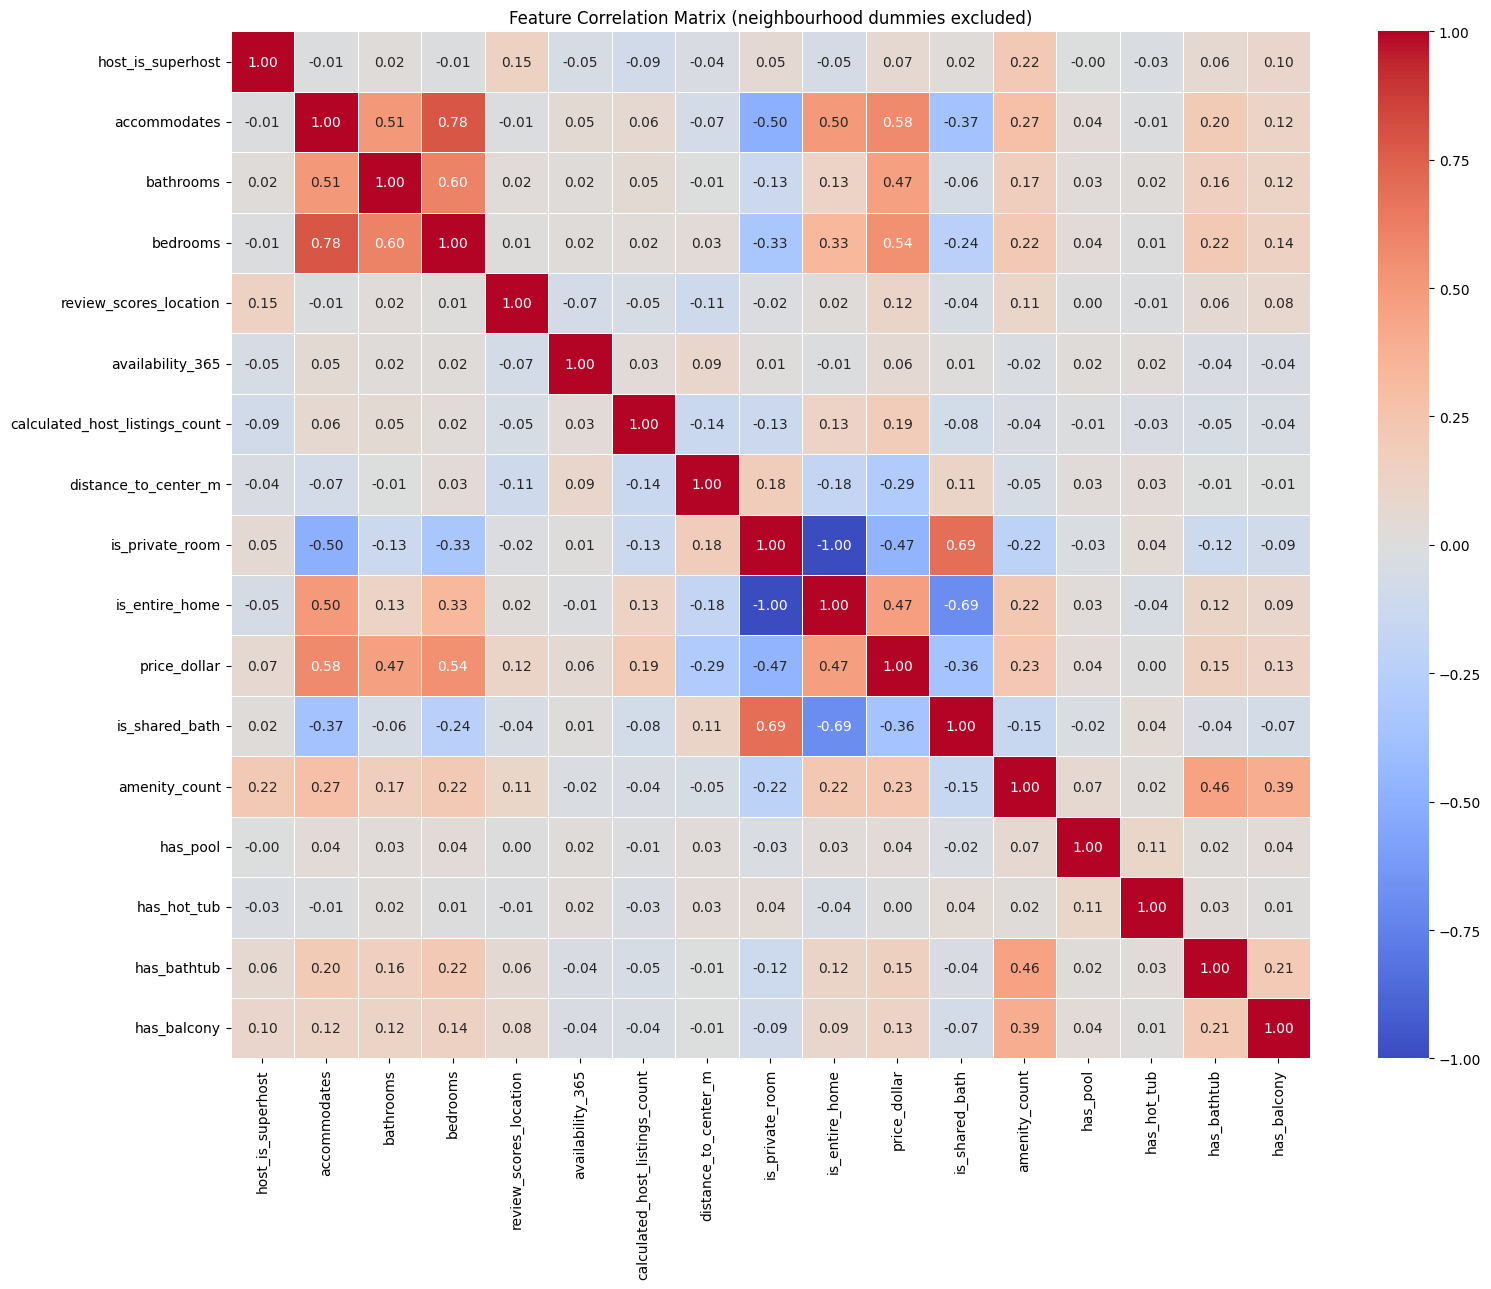

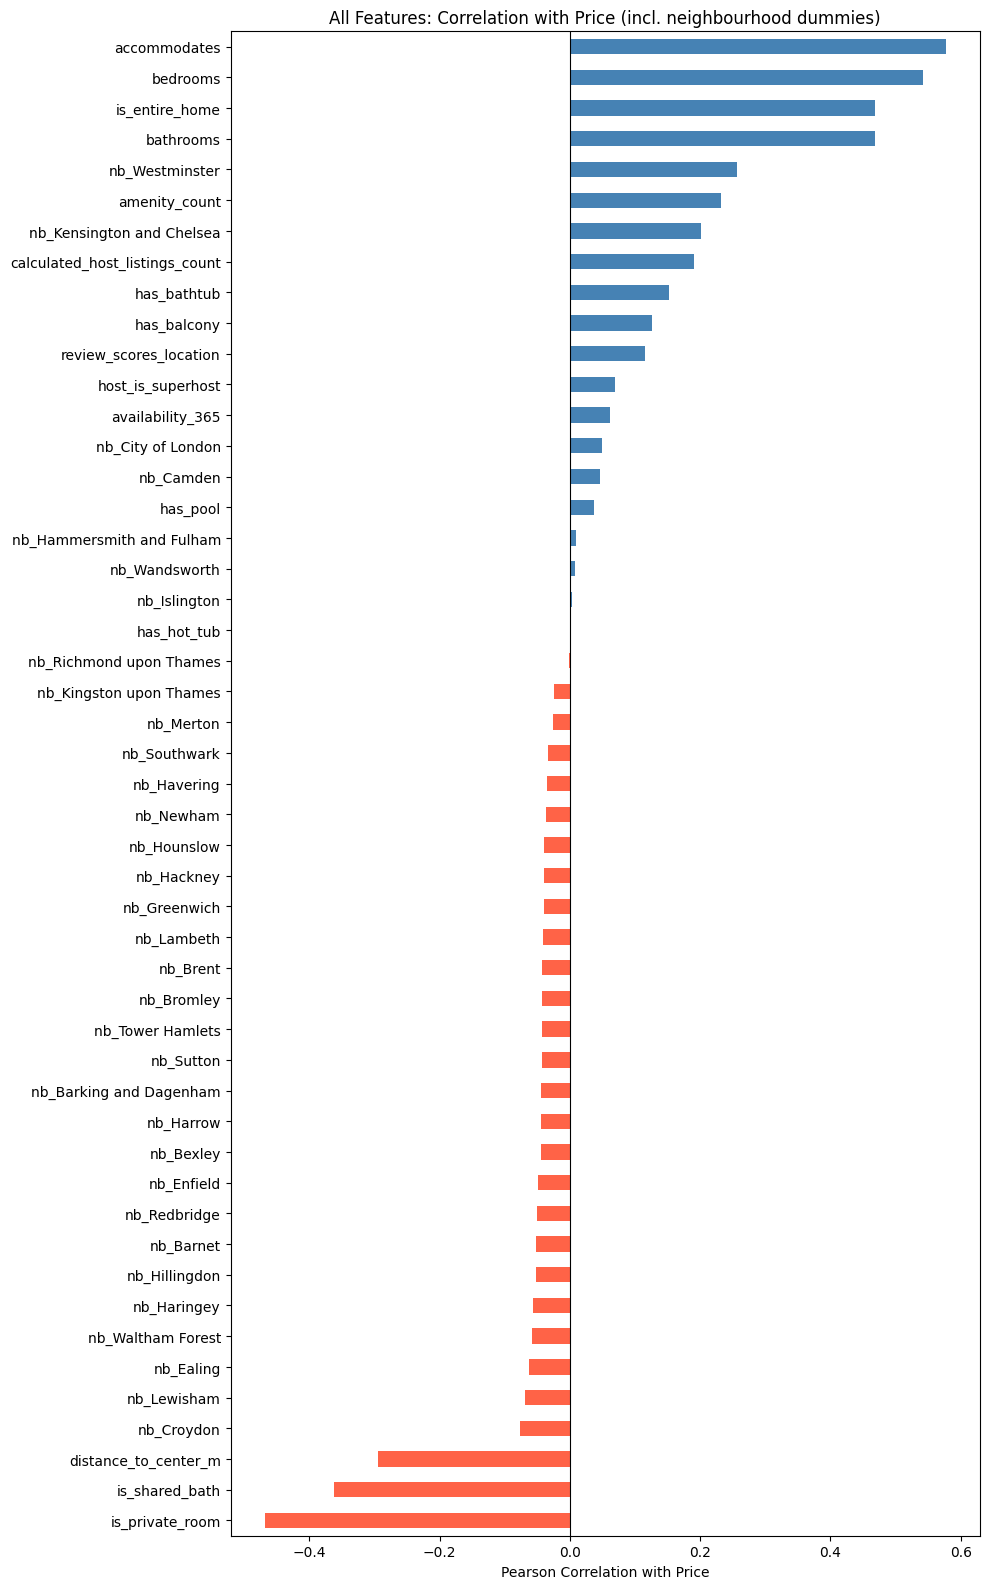

In [18]:
# ── Feature Correlation Analysis ──────────────────────────────────────────────
#
# Plot 1 — Heatmap of all engineered features (neighbourhood dummies excluded).
#   The 33 nb_* columns are one-hot encoded and mutually exclusive, so their
#   cross-correlations are uninformative and would make the matrix unreadable.
#
# Plot 2 — Bar chart of EVERY feature's correlation with price, including the
#   neighbourhood dummies. This shows which boroughs push prices up or down.

non_dummy_cols = [c for c in df.columns if not c.startswith('nb_')]
corr_matrix = df[non_dummy_cols].corr()

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.4,
    ax=ax,
)
ax.set_title('Feature Correlation Matrix (neighbourhood dummies excluded)')
plt.tight_layout()
plt.show()

# ── All features vs price (including neighbourhood dummies) ───────────────────
price_corr = df.corr(numeric_only=True)['price_dollar'].drop('price_dollar').sort_values()

colors = ['tomato' if v < 0 else 'steelblue' for v in price_corr]
fig, ax = plt.subplots(figsize=(10, 16))
price_corr.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with Price')
ax.set_title('All Features: Correlation with Price (incl. neighbourhood dummies)')
plt.tight_layout()
plt.show()

In [19]:
# ── Prepare Features and Target ───────────────────────────────────────────────
X = df.drop(columns='price_dollar')
y = np.log1p(df['price_dollar'])  # log-transform: makes the skewed price distribution easier to predict

# ── Hyperparameter Tuning with Optuna (using first seed) ─────────────────────
# Split data: 80% for training, 20% held out for final testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seeds[0])

# Standardize features: subtract mean, divide by std.
# Important: fit ONLY on training data to avoid leaking test information.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Further split training data into train/validation for Optuna's early stopping
X_tr, X_val, y_tr, y_val = train_test_split(X_train_scaled, y_train, test_size=0.2, random_state=seeds[0])

def objective(trial):
    """
    Optuna calls this function once per trial.
    It trains XGBoost with a suggested set of hyperparameters and
    returns the validation RMSE — Optuna tries to minimize this value.
    """
    params = {
        'n_estimators':          1000,
        'early_stopping_rounds': 50,        # stop early if val-RMSE stops improving
        'eval_metric':           'rmse',
        'learning_rate':         trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth':             trial.suggest_int('max_depth', 3, 10),
        'subsample':             trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':      trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight':      trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha':             trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda':            trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'random_state':          seeds[0],
        'verbosity':             0,
    }
    model = xgb.XGBRegressor(**params)
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    preds = model.predict(X_val)
    return root_mean_squared_error(y_val, preds)

# Run hyperparameter search (increase n_trials for better results)
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

print(f"Best Val RMSE : {study.best_value:.4f}")
print(f"Best Params   : {study.best_params}")

# ── Evaluate Across Multiple Seeds ────────────────────────────────────────────
# We re-train the model with the best hyperparameters on different random splits.
# Averaging RMSE across all seeds gives a more reliable estimate of real-world
# performance than a single train/test split.
best_params = study.best_params | {
    'n_estimators':          1000,
    'early_stopping_rounds': 50,
    'eval_metric':           'rmse',
    'verbosity':             0,
}

rmse_scores = []

for seed in seeds:
    # Create a fresh train/test split using this seed
    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X, y, test_size=0.2, random_state=seed)

    # Fit a new scaler on this seed's training data only (prevents data leakage)
    scaler_s = StandardScaler()
    X_train_s_scaled = scaler_s.fit_transform(X_train_s)
    X_test_s_scaled  = scaler_s.transform(X_test_s)

    # Validation split for early stopping
    X_tr_s, X_val_s, y_tr_s, y_val_s = train_test_split(
        X_train_s_scaled, y_train_s, test_size=0.2, random_state=seed
    )

    # Train with the best hyperparameters found by Optuna
    model = xgb.XGBRegressor(**best_params, random_state=seed)
    model.fit(X_tr_s, y_tr_s, eval_set=[(X_val_s, y_val_s)], verbose=False)

    # Convert log-predictions back to dollar values, then compute RMSE
    y_pred_s = np.expm1(model.predict(X_test_s_scaled))
    y_true_s = np.expm1(y_test_s)
    rmse_s   = root_mean_squared_error(y_true_s, y_pred_s)

    rmse_scores.append(rmse_s)
    print(f"Seed {seed:>3}: Test RMSE = ${rmse_s:.2f}")

print(f"\nMean RMSE : ${np.mean(rmse_scores):.2f}  ±  ${np.std(rmse_scores):.2f}")

# Keep the last trained model for the feature importance plots below
final_model = model

Best Val RMSE : 0.3078
Best Params   : {'learning_rate': 0.024727033198259245, 'max_depth': 10, 'subsample': 0.7533331413740223, 'colsample_bytree': 0.5871871785216265, 'min_child_weight': 9, 'reg_alpha': 2.5002130256803054e-05, 'reg_lambda': 3.7477305248003415e-05}


Seed   1: Test RMSE = $72.43


Seed   7: Test RMSE = $70.50


Seed  42: Test RMSE = $69.43


Seed  67: Test RMSE = $72.96


Seed  99: Test RMSE = $74.37

Mean RMSE : $71.94  ±  $1.76


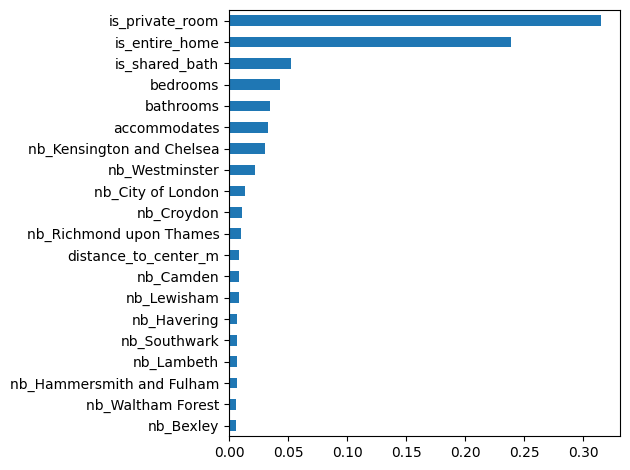

In [20]:
importances = pd.Series(final_model.feature_importances_, index=X.columns)
importances.sort_values().tail(20).plot(kind='barh')
plt.tight_layout()
plt.show()

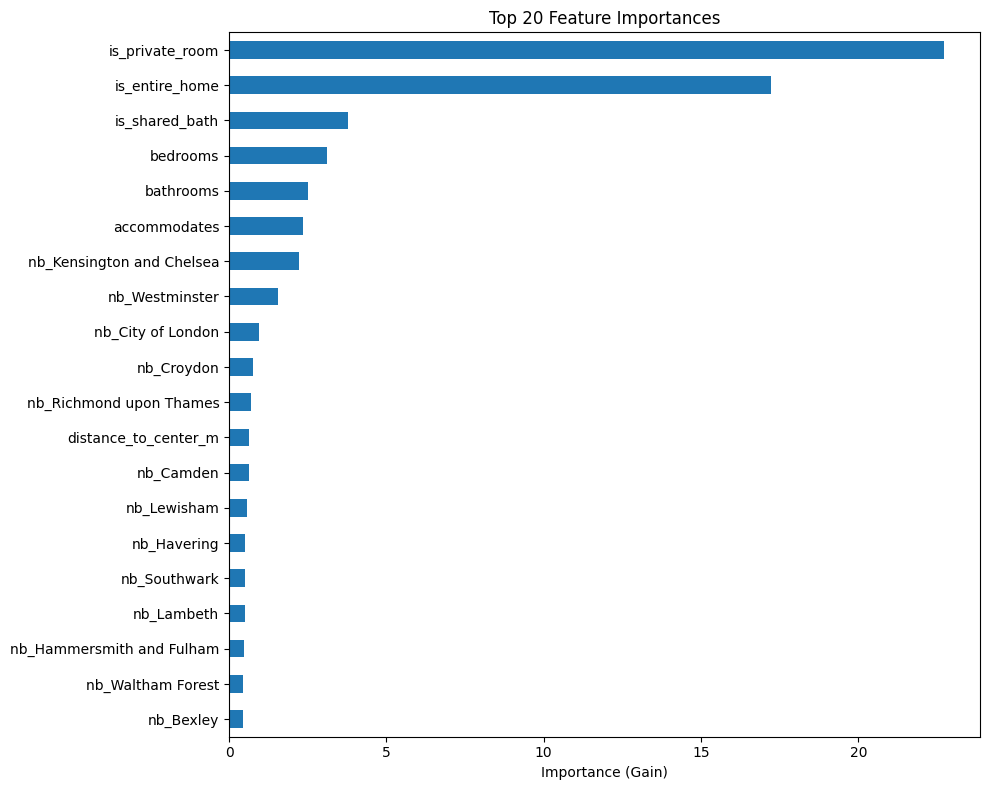

In [21]:
# Plot feature importance by "gain" — how much each feature reduces prediction error on average.
# This is more informative than the default "weight" metric (which just counts splits).
booster = final_model.get_booster()
booster.feature_names = list(X.columns)

importance_dict = booster.get_score(importance_type='gain')
importances = pd.Series(importance_dict).sort_values()

importances.tail(20).plot(kind='barh', figsize=(10, 8))
plt.xlabel('Importance (Gain)')
plt.title('Top 20 Feature Importances')
plt.tight_layout()
plt.show()

In [22]:
# ── Linear Regression ─────────────────────────────────────────────────────────
# The simplest baseline: assumes a straight-line relationship between each
# feature and the (log) price. No hyperparameters to tune.

rmse_lr = []

for seed in seeds:
    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X, y, test_size=0.2, random_state=seed)

    scaler_s = StandardScaler()
    X_train_s_scaled = scaler_s.fit_transform(X_train_s)
    X_test_s_scaled  = scaler_s.transform(X_test_s)

    model_lr = LinearRegression()
    model_lr.fit(X_train_s_scaled, y_train_s)

    y_pred = np.expm1(model_lr.predict(X_test_s_scaled))
    y_true = np.expm1(y_test_s)
    rmse   = root_mean_squared_error(y_true, y_pred)

    rmse_lr.append(rmse)
    print(f"Seed {seed:>3}: Test RMSE = ${rmse:.2f}")

print(f"\nLinear Regression  —  Mean RMSE: ${np.mean(rmse_lr):.2f}  ±  ${np.std(rmse_lr):.2f}")

Seed   1: Test RMSE = $85.05
Seed   7: Test RMSE = $84.21
Seed  42: Test RMSE = $82.94
Seed  67: Test RMSE = $93.73
Seed  99: Test RMSE = $87.49

Linear Regression  —  Mean RMSE: $86.68  ±  $3.82


In [23]:
# ── Ridge Regression ──────────────────────────────────────────────────────────
# Like linear regression but adds an L2 penalty that shrinks large coefficients.
# This reduces overfitting when features are correlated (as our neighbourhood
# dummies are). RidgeCV automatically picks the best penalty strength (alpha)
# via 5-fold cross-validation on the training set.

ALPHAS = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]

rmse_ridge = []

for seed in seeds:
    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X, y, test_size=0.2, random_state=seed)

    scaler_s = StandardScaler()
    X_train_s_scaled = scaler_s.fit_transform(X_train_s)
    X_test_s_scaled  = scaler_s.transform(X_test_s)

    model_ridge = RidgeCV(alphas=ALPHAS, cv=5)
    model_ridge.fit(X_train_s_scaled, y_train_s)

    y_pred = np.expm1(model_ridge.predict(X_test_s_scaled))
    y_true = np.expm1(y_test_s)
    rmse   = root_mean_squared_error(y_true, y_pred)

    rmse_ridge.append(rmse)
    print(f"Seed {seed:>3}: Test RMSE = ${rmse:.2f}  (best alpha = {model_ridge.alpha_})")

print(f"\nRidge Regression   —  Mean RMSE: ${np.mean(rmse_ridge):.2f}  ±  ${np.std(rmse_ridge):.2f}")

Seed   1: Test RMSE = $85.05  (best alpha = 10.0)


Seed   7: Test RMSE = $84.21  (best alpha = 10.0)


Seed  42: Test RMSE = $82.94  (best alpha = 10.0)


Seed  67: Test RMSE = $93.73  (best alpha = 10.0)


Seed  99: Test RMSE = $87.49  (best alpha = 10.0)

Ridge Regression   —  Mean RMSE: $86.69  ±  $3.82


In [24]:
# ── Neural Network ────────────────────────────────────────────────────────────
# A multi-layer perceptron (MLP) with three hidden layers.
# It learns non-linear combinations of features — much more expressive than
# linear models, but also slower to train.
#
# Architecture:  input → 256 → 128 → 64 → output
# early_stopping=True holds out 10% of training data as an internal
# validation set and stops training when performance stops improving,
# which prevents overfitting.

rmse_nn = []

for seed in seeds:
    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X, y, test_size=0.2, random_state=seed)

    scaler_s = StandardScaler()
    X_train_s_scaled = scaler_s.fit_transform(X_train_s)
    X_test_s_scaled  = scaler_s.transform(X_test_s)

    model_nn = MLPRegressor(
        hidden_layer_sizes=(256, 128, 64),
        activation='relu',
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=seed,
        verbose=False,
    )
    model_nn.fit(X_train_s_scaled, y_train_s)

    y_pred = np.expm1(model_nn.predict(X_test_s_scaled))
    y_true = np.expm1(y_test_s)
    rmse   = root_mean_squared_error(y_true, y_pred)

    rmse_nn.append(rmse)
    print(f"Seed {seed:>3}: Test RMSE = ${rmse:.2f}")

print(f"\nNeural Network     —  Mean RMSE: ${np.mean(rmse_nn):.2f}  ±  ${np.std(rmse_nn):.2f}")

Seed   1: Test RMSE = $79.53


Seed   7: Test RMSE = $77.91


Seed  42: Test RMSE = $79.78


Seed  67: Test RMSE = $92.56


Seed  99: Test RMSE = $83.13

Neural Network     —  Mean RMSE: $82.58  ±  $5.27


Model                   Mean RMSE ($)    Std ($)
────────────────────────────────────────────────
XGBoost                $       71.94   ±$  1.76
Neural Network         $       82.58   ±$  5.27
Linear Regression      $       86.68   ±$  3.82
Ridge Regression       $       86.69   ±$  3.82


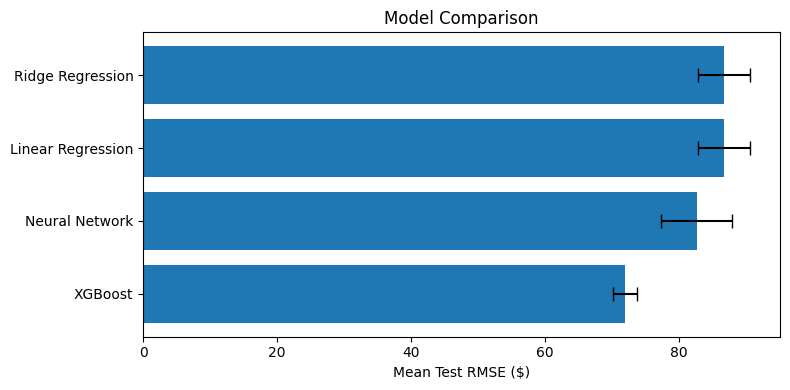

In [25]:
# ── Model Comparison ──────────────────────────────────────────────────────────
# Summary of all models, sorted by mean RMSE (lower = better).

results = {
    'Linear Regression': rmse_lr,
    'Ridge Regression':  rmse_ridge,
    'Neural Network':    rmse_nn,
    'XGBoost':           rmse_scores,
}

print(f"{'Model':<22} {'Mean RMSE ($)':>14} {'Std ($)':>10}")
print("─" * 48)
for name, scores in sorted(results.items(), key=lambda x: np.mean(x[1])):
    print(f"{name:<22} ${np.mean(scores):>12.2f}   ±${np.std(scores):>6.2f}")

# Bar chart for visual comparison
means = [np.mean(v) for v in results.values()]
stds  = [np.std(v)  for v in results.values()]
names = list(results.keys())

order = np.argsort(means)
plt.figure(figsize=(8, 4))
plt.barh(
    [names[i] for i in order],
    [means[i] for i in order],
    xerr=[stds[i] for i in order],
    capsize=5,
)
plt.xlabel('Mean Test RMSE ($)')
plt.title('Model Comparison')
plt.tight_layout()
plt.show()

Model                   Before ($)  After ($)    Change
────────────────────────────────────────────────────────
XGBoost                  $   74.92   $   71.94   ▼ 2.98
Neural Network           $   84.40   $   82.58   ▼ 1.82
Linear Regression        $   87.85   $   86.68   ▼ 1.17
Ridge Regression         $   87.85   $   86.69   ▼ 1.16


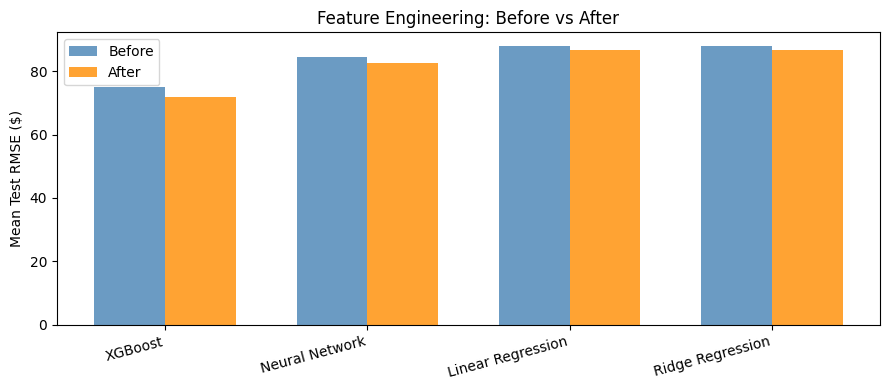

In [26]:
# ── Before vs After: Feature Engineering Impact ───────────────────────────────
# These baseline values were recorded BEFORE the feature improvements:
#   - had has_wifi (98.3% constant) and has_kitchen (91.5% constant)
#   - had beds (corr 0.805 with accommodates — redundant)
#   - used review_scores_rating (corr +0.032) instead of review_scores_location (+0.132)
#   - was missing calculated_host_listings_count (corr +0.218, strongest unused signal)

baseline = {
    'XGBoost':           74.92,
    'Neural Network':    84.40,
    'Linear Regression': 87.85,
    'Ridge Regression':  87.85,
}
after = {
    'XGBoost':           np.mean(rmse_scores),
    'Neural Network':    np.mean(rmse_nn),
    'Linear Regression': np.mean(rmse_lr),
    'Ridge Regression':  np.mean(rmse_ridge),
}

print(f"{'Model':<22} {'Before ($)':>11} {'After ($)':>10} {'Change':>9}")
print("─" * 56)
for name in ['XGBoost', 'Neural Network', 'Linear Regression', 'Ridge Regression']:
    b, a = baseline[name], after[name]
    delta = a - b
    tag = f"{'▼' if delta < 0 else '▲'} {abs(delta):.2f}"
    print(f"{name:<22}   ${b:>8.2f}   ${a:>8.2f}   {tag}")

# Grouped bar chart
models = list(baseline.keys())
x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - width / 2, [baseline[m] for m in models], width, label='Before', color='steelblue',  alpha=0.8)
ax.bar(x + width / 2, [after[m]    for m in models], width, label='After',  color='darkorange', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha='right')
ax.set_ylabel('Mean Test RMSE ($)')
ax.set_title('Feature Engineering: Before vs After')
ax.legend()
plt.tight_layout()
plt.show()